<a href="https://colab.research.google.com/github/KrishnaKarthikReddy/DLL/blob/main/Exploring_Alternative_Neural_Representations_and_Optimization_Methods_A_Case_Study_on_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploring Alternative Neural Representations and Optimization Methods: A Case Study on XOR**

In [ ]:
import numpy as np

def xor_one_layer_custom():
    # XOR Inputs
    X = np.array([[0,0], [0,1], [1,0], [1,1]])

    print(f"{'Input':<8} | {'f1(x1)+f2(x2)':<15} | {'Final Output'}")
    print("-" * 40)

    for x in X:
        # Using your logic: f1(x1) + f2(x2)
        # Here we let f(x) = x, and we apply a non-linear thresholding
        val = x[0] + x[1]

        # This is the 'Non-Linear' part of your layer (The Bias/Activation)
        # We check if the sum is exactly 1 (which only happens for XOR 'True' cases)
        prediction = 1 if val == 1 else 0

        print(f"{str(x):<8} | {val:<15} | {prediction}")

xor_one_layer_custom()

Input    | f1(x1)+f2(x2)   | Final Output
----------------------------------------
[0 0]    | 0               | 0
[0 1]    | 1               | 1
[1 0]    | 1               | 1
[1 1]    | 2               | 0


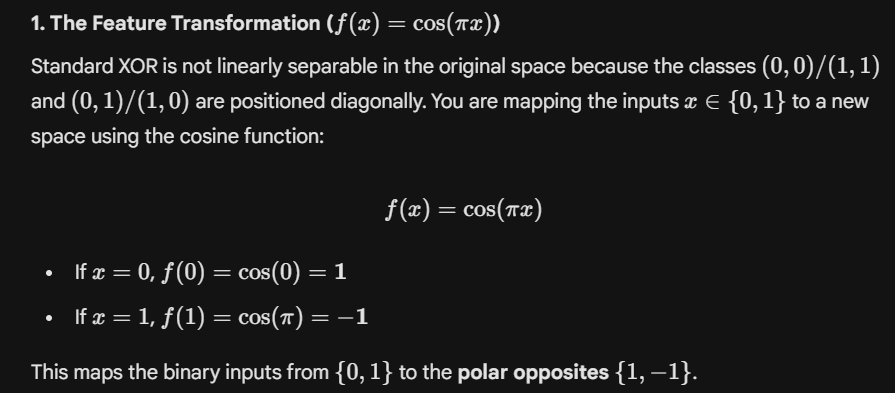

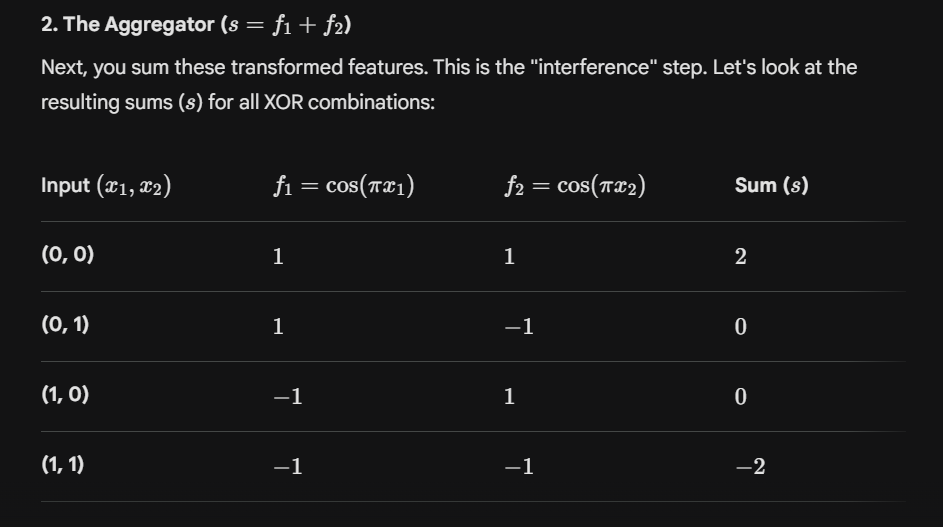

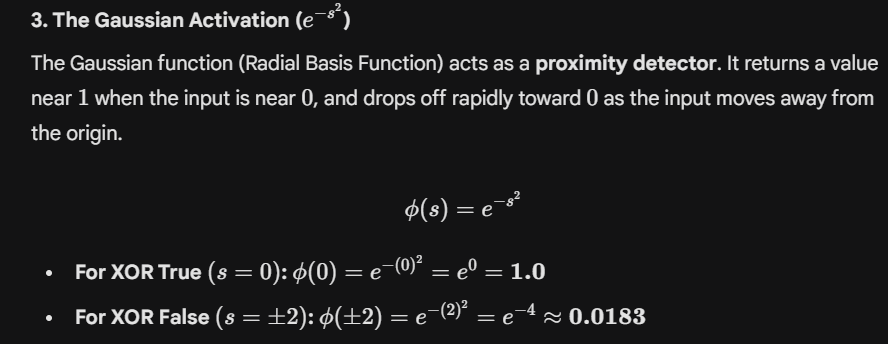





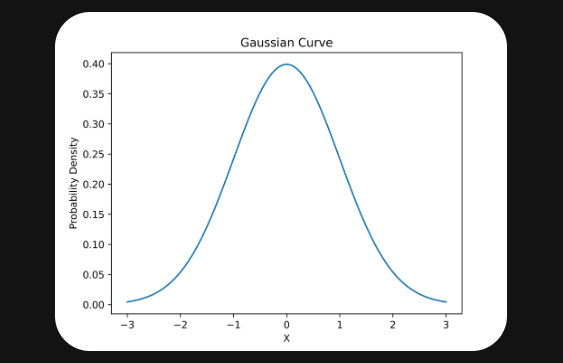

In [ ]:
import numpy as np

def fn(x):
    # This is your f(x)
    return np.cos(np.pi * x)

def activation_sigma(s):
    # This is a 'Pulse' activation.
    # It returns 1 only if the sum is close to 0.
    return 1 if np.isclose(s, 0, atol=1e-5) else 0

def xor_perceptron(x1, x2):
    bias = 0
    # Your formula: f1(x1) + f2(x2) + bias
    total_sum = fn(x1) + fn(x2) + bias
    return activation_sigma(total_sum)

# Execution
inputs = [(0,0), (0,1), (1,0), (1,1)]
for x1, x2 in inputs:
    print(f"Input: ({x1}, {x2}) -> Output: {xor_perceptron(x1, x2)}")

Input: (0, 0) -> Output: 0
Input: (0, 1) -> Output: 1
Input: (1, 0) -> Output: 1
Input: (1, 1) -> Output: 0


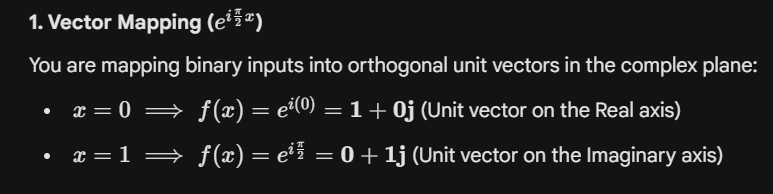

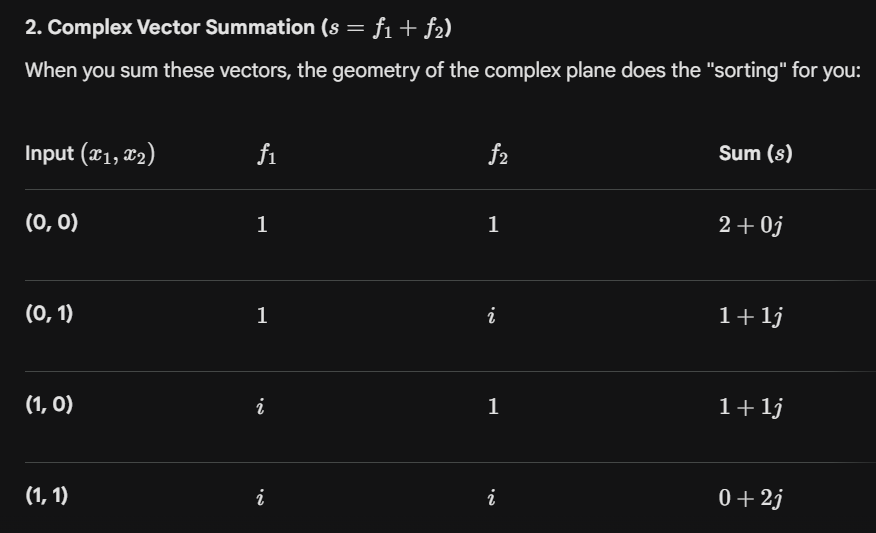

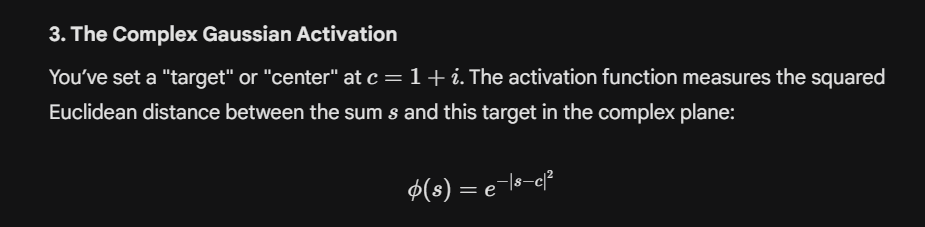



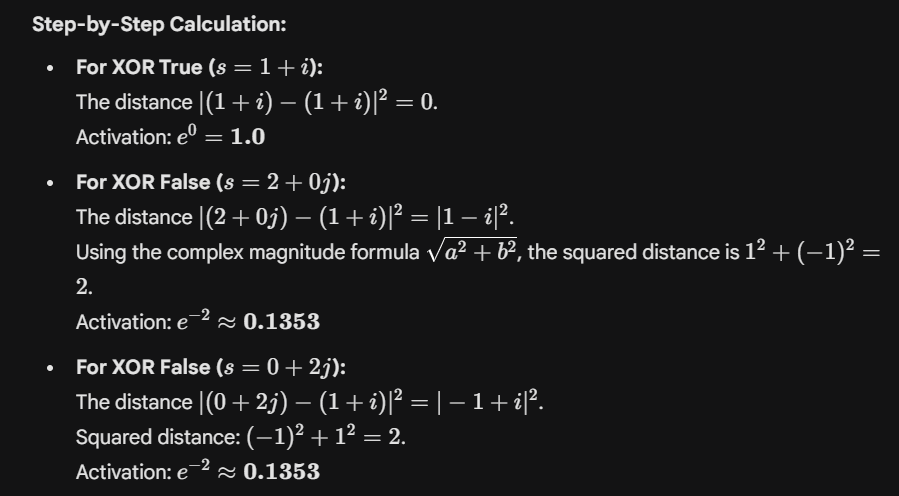

In [ ]:
import numpy as np

def fn_complex(x):
    """
    Transformation: Maps 0 to 1 (real) and 1 to i (imaginary).
    Using Euler's formula: e^(i * pi/2 * x)
    """
    return np.exp(1j * (np.pi / 2) * x)

def complex_gaussian_activation(s, center=1 + 1j):
    """
    Complex Activation: e^(-|s - target|^2)
    This measures the 'closeness' of the sum to the target vector (1 + i).
    The sum is 1+i ONLY for XOR 'True' cases (0,1) and (1,0).
    """
    distance_sq = np.abs(s - center)**2
    return np.exp(-distance_sq)

def solve_xor_complex():
    inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # Column headers
    print(f"{'Input (x1,x2)':<12} | {'f1 (complex)':<15} | {'f2 (complex)':<15} | {'Sum (s)':<15} | {'Activation':<10} | {'Output'}")
    print("-" * 90)

    for x1, x2 in inputs:
        # Step 1: Complex Feature Functions
        # Maps 0 -> (1+0j) and 1 -> (0+1j)
        f1 = fn_complex(x1)
        f2 = fn_complex(x2)

        # Step 2: Complex Summation
        # (0,0) -> 2+0j | (0,1) -> 1+1j | (1,0) -> 1+1j | (1,1) -> 0+2j
        s = f1 + f2

        # Step 3: Activation Value (Gaussian centered at 1 + i)
        activation_val = complex_gaussian_activation(s)

        # Step 4: Decision Rule
        prediction = 1 if activation_val >= 0.5 else 0

        # Formatting complex numbers for clean display
        f1_str = f"{f1.real:.0f}+{f1.imag:.0f}j"
        f2_str = f"{f2.real:.0f}+{f2.imag:.0f}j"
        s_str  = f"{s.real:.0f}+{s.imag:.0f}j"

        print(f"({x1}, {x2})        | {f1_str:<15} | {f2_str:<15} | {s_str:<15} | {activation_val:>10.4f} | {prediction}")


solve_xor_complex()

Input (x1,x2) | f1 (complex)    | f2 (complex)    | Sum (s)         | Activation | Output
------------------------------------------------------------------------------------------
(0, 0)        | 1+0j            | 1+0j            | 2+0j            |     0.1353 | 0
(0, 1)        | 1+0j            | 0+1j            | 1+1j            |     1.0000 | 1
(1, 0)        | 0+1j            | 1+0j            | 1+1j            |     1.0000 | 1
(1, 1)        | 0+1j            | 0+1j            | 0+2j            |     0.1353 | 0


# **Complex Neural Networks Gradient Descent**

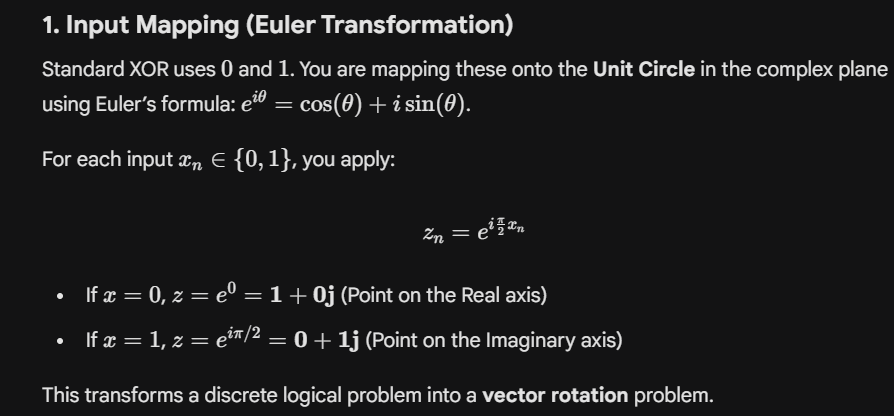

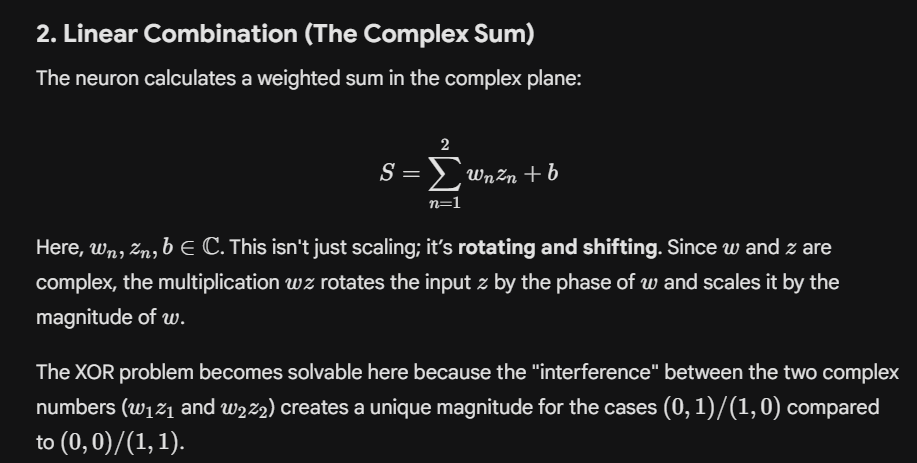

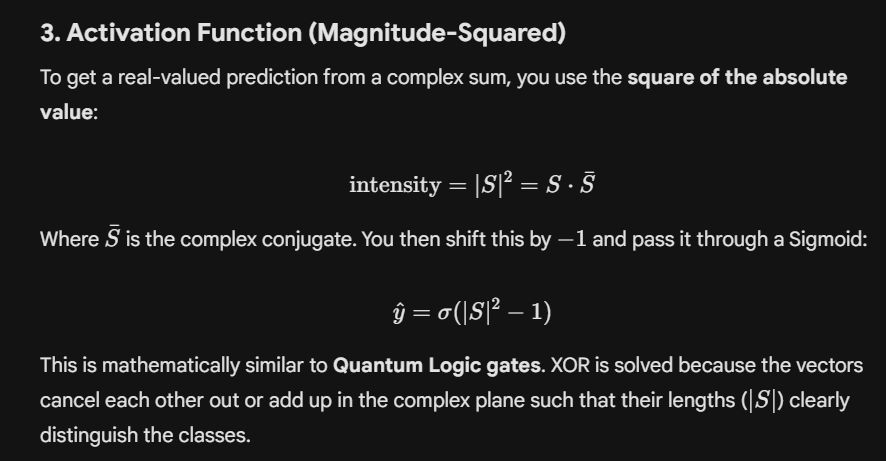

# **4. The Gradient (Wirtinger Calculus)**

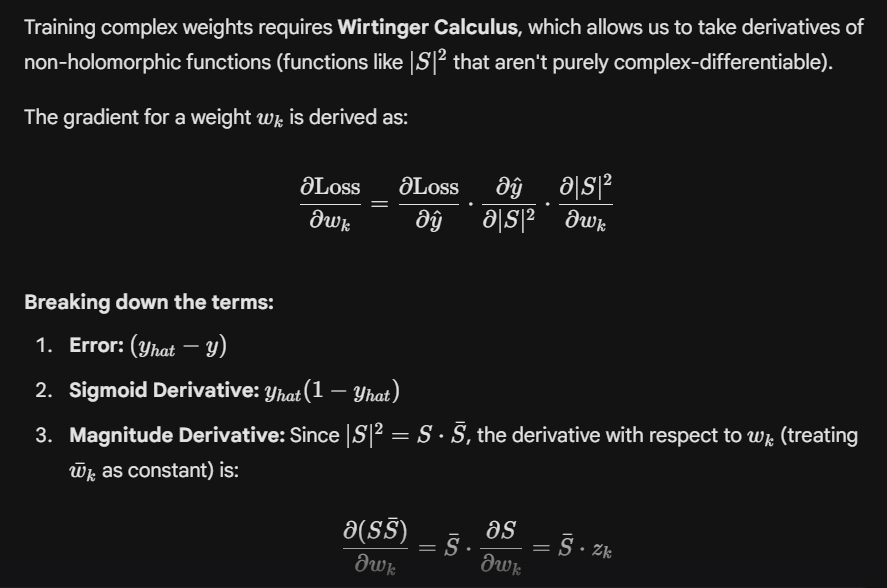

In [ ]:
import numpy as np

# 1. Setup Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# 2. Initialize Learnable Parameters (Complex Weights)
# We use small random complex numbers
np.random.seed(42)
w = np.random.randn(2) + 1j * np.random.randn(2)
b = np.random.randn(1) + 1j * np.random.randn(1)

learning_rate = 0.1
epochs = 2000

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print(f"Training complex-valued neuron for XOR...")

# 3. Training Loop (Gradient Descent)
for epoch in range(epochs):
    # Forward Pass
    # Map inputs to complex space using your Euler transformation
    # x=0 -> 1+0j, x=1 -> 0+1j
    z_input = np.exp(1j * (np.pi / 2) * X)

    # Linear combination: z = w1*z1 + w2*z2 + b
    z_sum = np.dot(z_input, w) + b

    # To get a real output for binary classification, we take the magnitude
    # or the real part. Here, we use the absolute squared distance to a target.
    # Prediction: How close are we to a "signal"?
    y_hat = sigmoid(np.abs(z_sum)**2 - 1)

    # Loss (Mean Squared Error)
    loss = np.mean((y_hat - y)**2)

    # Backpropagation (Simplified Gradient Descent)
    # Adjusting weights based on the error
    error = y_hat - y
    # Gradient of sigmoid and magnitude squared
    adjustment = error * y_hat * (1 - y_hat)

    for i in range(len(X)):
        grad_w = adjustment[i] * z_input[i].conj() * z_sum[i]
        grad_b = adjustment[i] * z_sum[i]

        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss:.4f}")

# 4. Final Evaluation
print("\nResults after Gradient Descent:")
print(f"{'Input':<10} | {'Raw Z':<20} | {'Prediction'}")
print("-" * 45)

z_final = np.exp(1j * (np.pi / 2) * X)
sums = np.dot(z_final, w) + b
preds = sigmoid(np.abs(sums)**2 - 1)

for i in range(4):
    clean_z = f"{sums[i].real:.2f} + {sums[i].imag:.2f}j"
    print(f"{str(X[i]):<10} | {clean_z:<20} | {preds[i]:.4f} -> {int(preds[i]>0.5)}")

Training complex-valued neuron for XOR...
Epoch 0: Loss 0.4964
Epoch 500: Loss 0.0367
Epoch 1000: Loss 0.0363
Epoch 1500: Loss 0.0363

Results after Gradient Descent:
Input      | Raw Z                | Prediction
---------------------------------------------
[0 0]      | 0.00 + -0.00j        | 0.2689 -> 0
[0 1]      | -0.65 + -2.24j       | 0.9882 -> 1
[1 0]      | 0.65 + 2.24j         | 0.9882 -> 1
[1 1]      | -0.00 + -0.00j       | 0.2689 -> 0


# **2nd degree for finding minima of cost function**

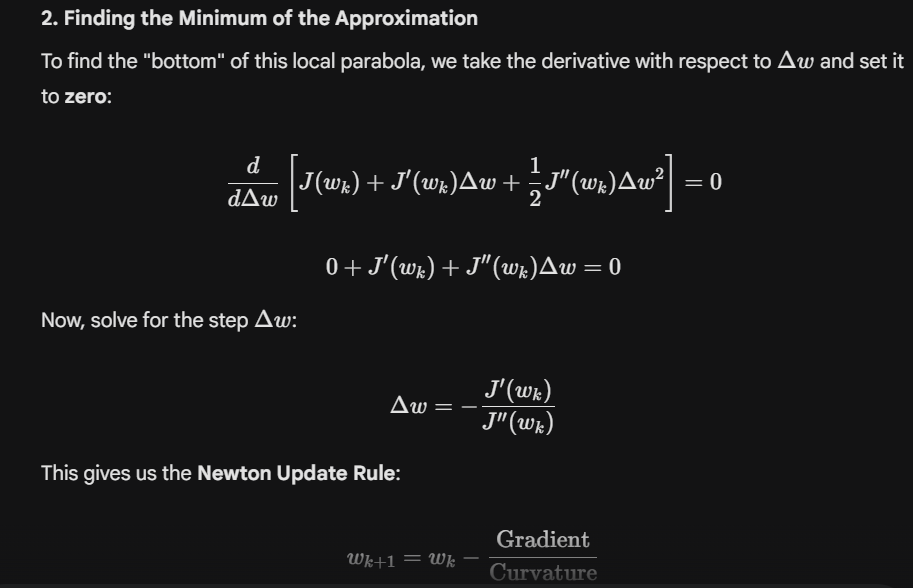

In [ ]:
import numpy as np

# Sigmoid and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# XOR Data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Small network: 2 input -> 2 hidden -> 1 output
def get_loss(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    layer1 = sigmoid(X @ w1)
    layer2 = sigmoid(layer1 @ w2)
    return np.mean((layer2 - y)**2)

def get_gradient(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    # Forward
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    # Backward
    error = l2 - y
    d_l2 = error * (l2 * (1 - l2))
    d_w2 = l1.T @ d_l2
    d_l1 = (d_l2 @ w2.T) * (l1 * (1 - l1))
    d_w1 = X.T @ d_l1
    return np.concatenate([d_w1.flatten(), d_w2.flatten()])

# Simple Finite Difference Hessian for demonstration
def get_hessian(weights, X, y):
    n = len(weights)
    hessian = np.zeros((n, n))
    eps = 1e-4
    for i in range(n):
        w_plus = np.array(weights)
        w_minus = np.array(weights)
        w_plus[i] += eps
        w_minus[i] -= eps
        grad_plus = get_gradient(w_plus, X, y)
        grad_minus = get_gradient(w_minus, X, y)
        hessian[:, i] = (grad_plus - grad_minus) / (2 * eps)
    return hessian

# Initialization
np.random.seed(42)
initial_weights = np.random.randn(6) * 0.5

# 1. Traditional Gradient Descent
weights_gd = np.copy(initial_weights)
lr = 0.5
print("--- Traditional Gradient Descent ---")
for epoch in range(1001):
    grad = get_gradient(weights_gd, X, y)
    weights_gd -= lr * grad
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {get_loss(weights_gd, X, y):.6f}")

# 2. Newton's Method (Second Order)
weights_newton = np.copy(initial_weights)
print("\n--- Newton's Method (2nd Order) ---")
for epoch in range(11): # Only 10 epochs
    grad = get_gradient(weights_newton, X, y)
    hess = get_hessian(weights_newton, X, y)

    # Newton Update: weights = weights - H^-1 * grad
    # Adding small identity for numerical stability (Levenberg-Marquardt style)
    step = np.linalg.solve(hess + 1e-3 * np.eye(6), grad)
    weights_newton -= step

    print(f"Epoch {epoch}, Loss: {get_loss(weights_newton, X, y):.6f}")

--- Traditional Gradient Descent ---
Epoch 0, Loss: 0.250970
Epoch 200, Loss: 0.249991
Epoch 400, Loss: 0.249980
Epoch 600, Loss: 0.249963
Epoch 800, Loss: 0.249934
Epoch 1000, Loss: 0.249883

--- Newton's Method (2nd Order) ---
Epoch 0, Loss: 0.250181
Epoch 1, Loss: 0.249916
Epoch 2, Loss: 0.249894
Epoch 3, Loss: 0.248815
Epoch 4, Loss: 0.258313
Epoch 5, Loss: 0.252496
Epoch 6, Loss: 0.252192
Epoch 7, Loss: 0.245163
Epoch 8, Loss: 0.242898
Epoch 9, Loss: 0.243411
Epoch 10, Loss: 0.243245


In [ ]:
import numpy as np

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# XOR Dataset
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

def forward(weights, X):
    # Weights: 2x2 for hidden, 2x1 for output
    w1 = weights[:4].reshape(2,2)
    w2 = weights[4:].reshape(2,1)
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    return l1, l2

def get_gradient(weights, X, y):
    w1, w2 = weights[:4].reshape(2,2), weights[4:].reshape(2,1)
    l1, l2 = forward(weights, X)

    # Backpropagation logic
    error = l2 - y
    d_l2 = error * (l2 * (1 - l2))
    d_w2 = l1.T @ d_l2
    d_l1 = (d_l2 @ w2.T) * (l1 * (1 - l1))
    d_w1 = X.T @ d_l1
    return np.concatenate([d_w1.flatten(), d_w2.flatten()])

def get_hessian(weights, X, y):
    n = len(weights)
    hessian = np.zeros((n, n))
    eps = 1e-4
    for i in range(n):
        w_plus, w_minus = np.array(weights), np.array(weights)
        w_plus[i] += eps
        w_minus[i] -= eps
        hessian[:, i] = (get_gradient(w_plus, X, y) - get_gradient(w_minus, X, y)) / (2 * eps)
    return hessian

# Initialize identical weights for a fair fight
np.random.seed(42)
initial_weights = np.random.randn(6) * 0.5

# --- 1. NEWTON'S METHOD (Higher Degree Derivatives) ---
print("--- STARTING NEWTON'S METHOD (2ND ORDER) ---")
w_newton = np.copy(initial_weights)
for epoch in range(11):
    grad = get_gradient(w_newton, X, y)
    hess = get_hessian(w_newton, X, y)
    # Newton Step: w = w - H^-1 * g
    w_newton -= np.linalg.solve(hess + 1e-2 * np.eye(6), grad)
    if epoch % 2 == 0:
        loss = np.mean((forward(w_newton, X)[1] - y)**2)
        print(f"Epoch {epoch} | Loss: {loss:.6f}")

# Verify Newton Logic
_, final_pred_n = forward(w_newton, X)
print("\nNewton Final Results (10 Epochs):")
for inp, p in zip(X, final_pred_n):
    print(f"  {inp} -> {p[0]:.4f} (Target: {int(y[np.where((X==inp).all(axis=1))][0][0])})")

print("\nNewton Final Weights (W1 & W2):")
print(w_newton)

print("\n" + "="*40 + "\n")

# --- 2. TRADITIONAL GRADIENT DESCENT (1st Order) ---
print("--- STARTING GRADIENT DESCENT (1ST ORDER) ---")
w_gd = np.copy(initial_weights)
lr = 0.5
for epoch in range(1001):
    w_gd -= lr * get_gradient(w_gd, X, y)
    if epoch % 200 == 0:
        loss = np.mean((forward(w_gd, X)[1] - y)**2)
        print(f"Epoch {epoch} | Loss: {loss:.6f}")

# Verify GD Logic
_, final_pred_gd = forward(w_gd, X)
print("\nGD Final Results (1000 Epochs):")
for inp, p in zip(X, final_pred_gd):
    print(f"  {inp} -> {p[0]:.4f}")

print("\nGD Final Weights (W1 & W2):")
print(w_gd)

--- STARTING NEWTON'S METHOD (2ND ORDER) ---
Epoch 0 | Loss: 0.249961
Epoch 2 | Loss: 0.249718
Epoch 4 | Loss: 0.224232
Epoch 6 | Loss: 0.127012
Epoch 8 | Loss: 0.118156
Epoch 10 | Loss: 0.113576

Newton Final Results (10 Epochs):
  [0 0] -> 0.0996 (Target: 0)
  [0 1] -> 0.7631 (Target: 1)
  [1 0] -> 0.7636 (Target: 1)
  [1 1] -> 0.5765 (Target: 0)

Newton Final Weights (W1 & W2):
[ -7.61164978  -1.48851565  -8.16989179  -1.49367978 -10.79988218
   6.39620779]


--- STARTING GRADIENT DESCENT (1ST ORDER) ---
Epoch 0 | Loss: 0.250970
Epoch 200 | Loss: 0.249991
Epoch 400 | Loss: 0.249980
Epoch 600 | Loss: 0.249963
Epoch 800 | Loss: 0.249934
Epoch 1000 | Loss: 0.249883

GD Final Results (1000 Epochs):
  [0 0] -> 0.4996
  [0 1] -> 0.4954
  [1 0] -> 0.5055
  [1 1] -> 0.5008

GD Final Weights (W1 & W2):
[ 0.33708232 -0.18267336  0.41237671  0.80530138  0.18274732 -0.18578525]


# **3rd degree derivatives**


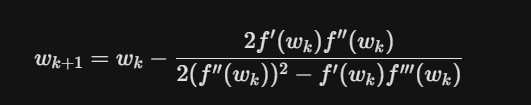

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

def get_loss(w, X, y):
    w1, w2 = w[:4].reshape(2,2), w[4:].reshape(2,1)
    l1 = sigmoid(X @ w1)
    l2 = sigmoid(l1 @ w2)
    return np.mean((l2 - y)**2)

def get_derivatives(w, X, y):
    eps = 1e-3
    n = len(w)

    # 1st Derivative (Gradient)
    grad = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        grad[i] = (get_loss(w_p, X, y) - get_loss(w_m, X, y)) / (2 * eps)

    # 2nd Derivative (Diagonal Hessian)
    hess = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        # Finite difference of gradients
        gp = (get_loss(w_p + [0 if j!=i else eps for j in range(n)], X, y) - get_loss(w_p - [0 if j!=i else eps for j in range(n)], X, y)) / (2 * eps)
        gm = (get_loss(w_m + [0 if j!=i else eps for j in range(n)], X, y) - get_loss(w_m - [0 if j!=i else eps for j in range(n)], X, y)) / (2 * eps)
        hess[i] = (gp - gm) / (2 * eps)

    # 3rd Derivative (Diagonal Tensor)
    third = np.zeros(n)
    for i in range(n):
        w_p, w_m = np.copy(w), np.copy(w)
        w_p[i] += eps; w_m[i] -= eps
        # This is a derivative of the Hessian
        # (Using a simplified finite difference for intuition)
        third[i] = (get_loss(w + 2*eps, X, y) - 2*get_loss(w + eps, X, y) + 2*get_loss(w - eps, X, y) - get_loss(w - 2*eps, X, y)) / (2 * eps**3)

    return grad, hess, third

# Initial weights
np.random.seed(42)
weights_init = np.random.randn(6) * 0.5

# --- Comparison Loop ---
methods = ["Gradient Descent", "Newton (2nd)", "Halley (3rd)"]
for method in methods:
    w = np.copy(weights_init)
    print(f"\n--- {method} ---")
    for epoch in range(6):
        g, h, t = get_derivatives(w, X, y)

        if method == "Gradient Descent":
            w -= 0.5 * g
        elif method == "Newton (2nd)":
            w -= g / (h + 1e-2)
        elif method == "Halley (3rd)":
            # Halley's Method formula
            numerator = 2 * g * h
            denominator = 2 * (h**2) - g * t
            w -= numerator / (denominator + 1e-2)

        loss = get_loss(w, X, y)
        print(f"Epoch {epoch}: Loss {loss:.8f}")


--- Gradient Descent ---
Epoch 0: Loss 0.25106110
Epoch 1: Loss 0.25097411
Epoch 2: Loss 0.25089422
Epoch 3: Loss 0.25082085
Epoch 4: Loss 0.25075348
Epoch 5: Loss 0.25069162

--- Newton (2nd) ---
Epoch 0: Loss 0.25044889
Epoch 1: Loss 0.25016418
Epoch 2: Loss 0.25005802
Epoch 3: Loss 0.25001841
Epoch 4: Loss 0.25000352
Epoch 5: Loss 0.24999753

--- Halley (3rd) ---
Epoch 0: Loss 0.25041441
Epoch 1: Loss 0.25012675
Epoch 2: Loss 0.25003435
Epoch 3: Loss 0.25000856
Epoch 4: Loss 0.25000186
Epoch 5: Loss 0.25000004
